  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Данные готовы: (1194, 31)

=== KMeans ===
k=2: 0.09555633725368658
k=3: 0.08847052662592449
k=4: 0.06526894311310724
k=5: 0.07471879107885591
k=6: 0.056780413363548395
k=7: 0.06141272917815235
k=8: 0.0650686045308983
k=9: 0.062020515811719815
k=10: 0.05159505539846743

=== GMM ===
k=2: 0.2631078196385676
k=3: 0.22918404724669716
k=4: 0.05403665401291051
k=5: 0.06129303658086115
k=6: 0.06378796824000897
k=7: 0.05174335019669866
k=8: 0.06395228879810996
k=9: 0.04632500801882247
k=10: 0.030807150741202466

=== Agglomerative ===
k=2: 0.06977514123475484
k=3: 0.07365490115703077
k=4: 0.077297592987284
k=5: 0.08770811298325862
k=6: 0.08280259107553384
k=7: 0.07919002107867444
k=8: 0.0916305282215139
k=9: 0.09132438048190855
k=10: 0.08515940845233605

=== Spectral ===
k=2: 0.37460346895968755
k=3: 0.1904416382882408
k=4: 0.19356447621486833
k=5: 0.192141429594

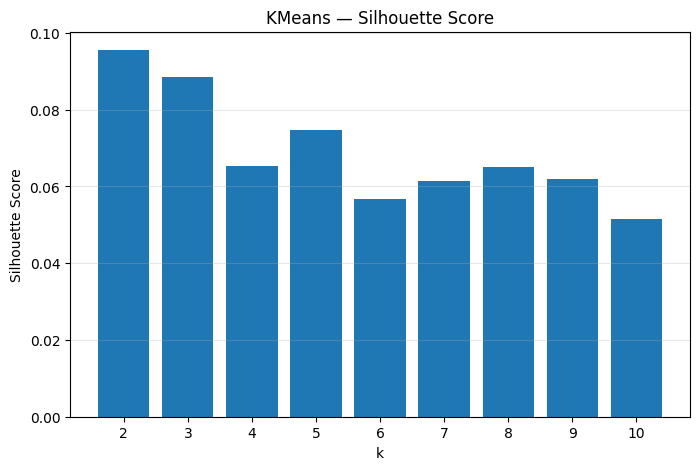

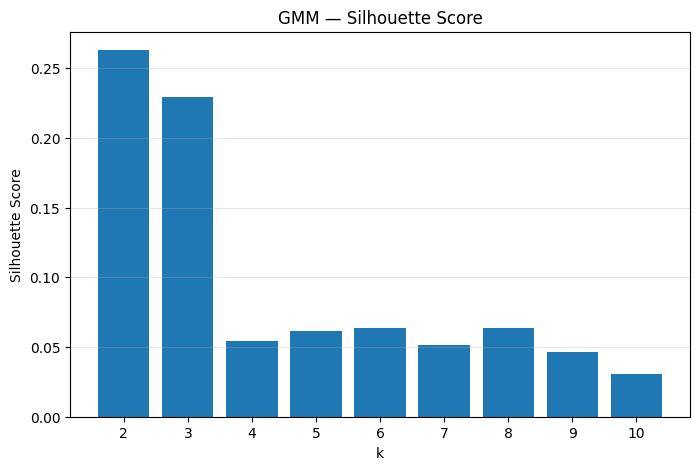

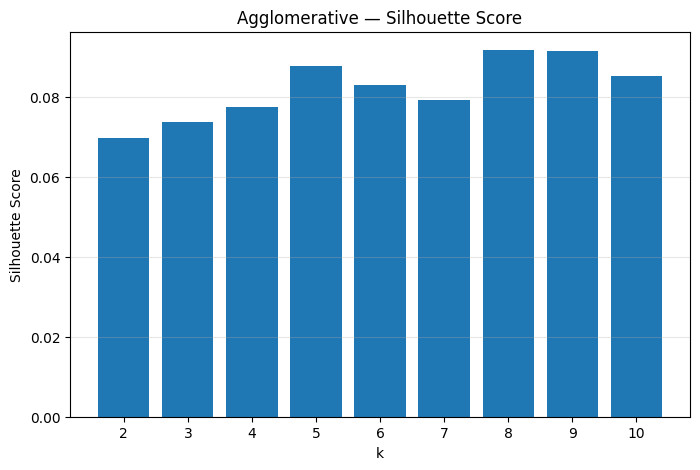

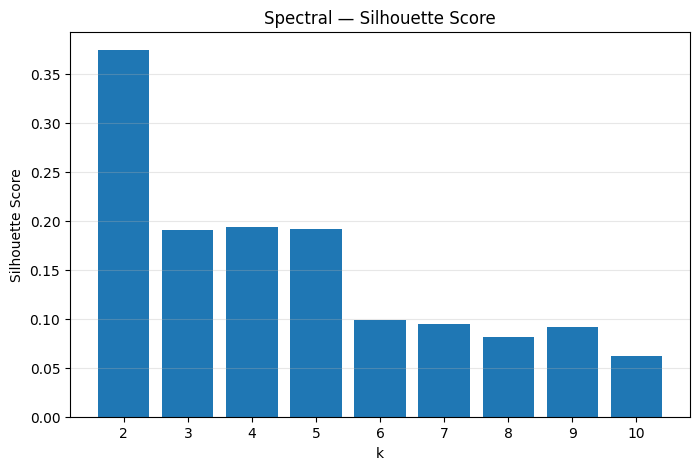

In [2]:
#!pip install scikit-learn-extra --quiet


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import OrdinalEncoder, StandardScaler
from sklearn.metrics import silhouette_score

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, SpectralClustering
from sklearn.mixture import GaussianMixture

#from sklearn_extra.cluster import KMedoids

file_path = "Students_Performance_data_set.xlsx"
df = pd.read_excel(file_path)

df.columns = [c.strip() for c in df.columns]

col_renames = {
    'University Admission year': 'admission_year',
    'Gender': 'gender',
    'Age': 'age',
    'H.S.C passing year': 'hsc_year',
    'Program': 'program',
    'Current Semester': 'current_semester',
    'Do you have meritorious scholarship ?': 'merit_scholarship',
    'Do you use University transportation?': 'use_transport',
    'How many hour do you study daily?': 'study_hours_daily',
    'How many times do you seat for study in a day?': 'study_freq_daily',
    'What is your preferable learning mode?': 'learning_mode',
    'Do you use smart phone?': 'use_smartphone',
    'Do you have personal Computer?': 'have_pc',
    'How many hour do you spent daily in social media?': 'social_media_hours',
    'Status of your English language proficiency': 'english_proficiency',
    'Average attendance on class': 'attendance_pct',
    'Did you ever fall in probation?': 'probation',
    'Did you ever got suspension?': 'suspension',
    'Do you attend in teacher consultancy for any kind of academical problems?': 'teacher_consultancy',
    'What are the skills do you have ?': 'skills',
    'How many hour do you spent daily on your skill development?': 'skill_hours_daily',
    'What is you interested area?': 'interest_area',
    'What is your relationship status?': 'relationship_status',
    'Are you engaged with any co-curriculum activities?': 'co_curriculum',
    'With whom you are living with?': 'living_with',
    'Do you have any health issues?': 'health_issues',
    'What was your previous SGPA?': 'prev_sgpa',
    'Do you have any physical disabilities?': 'physical_disability',
    'What is your current CGPA?': 'current_cgpa',
    'How many Credit did you have completed?': 'credits_completed',
    'What is your monthly family income?': 'monthly_income'
}

df = df.rename(columns={k: v for k, v in col_renames.items() if k in df.columns})

df.dropna(how="all", inplace=True)
df.dropna(axis=1, how="all", inplace=True)
df.drop_duplicates(inplace=True)

num_cols = df.select_dtypes(include=["int", "float"]).columns.tolist()
cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

if 'attendance_pct' in cat_cols:
    cat_cols.remove('attendance_pct')
    df['attendance_pct'] = pd.to_numeric(df['attendance_pct'], errors='coerce')
    num_cols.append('attendance_pct')

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

X = df.copy()

encoder = OrdinalEncoder()
X[cat_cols] = encoder.fit_transform(X[cat_cols])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Данные готовы:", X_scaled.shape)

def safe_silhouette(X, labels):
    if len(np.unique(labels)) < 2:
        return None
    try:
        return silhouette_score(X, labels)
    except:
        return None

def run_kmeans(k):
    return KMeans(n_clusters=k, random_state=42).fit_predict(X_scaled)

def run_gmm(k):
    return GaussianMixture(n_components=k, random_state=42).fit_predict(X_scaled)

def run_agg(k):
    return AgglomerativeClustering(n_clusters=k).fit_predict(X_scaled)

#def run_kmedoids(k):
#    return KMedoids(n_clusters=k, random_state=42).fit_predict(X_scaled)

def run_spectral(k):
    return SpectralClustering(n_clusters=k, affinity='nearest_neighbors', random_state=42).fit_predict(X_scaled)

def run_dbscan():
    return DBSCAN(eps=1.5, min_samples=1).fit_predict(X_scaled)


algorithms = {
    "KMeans": run_kmeans,
    "GMM": run_gmm,
    "Agglomerative": run_agg,
    #"K-Medoids": run_kmedoids,
    "Spectral": run_spectral
}

results = {}

for name, func in algorithms.items():
    print(f"\n=== {name} ===")
    scores = []

    for k in range(2, 11):
        labels = func(k)
        score = safe_silhouette(X_scaled, labels)
        scores.append(score)
        print(f"k={k}: {score}")

    results[name] = scores

print("\n=== DBSCAN ===")
db_labels = run_dbscan()
db_score = safe_silhouette(X_scaled, db_labels)
print("DBSCAN silhouette:", db_score)

for name, scores in results.items():
    plt.figure(figsize=(8, 5))

    ks = list(range(2, 11))
    scores_clean = [s if s is not None else 0 for s in scores]

    plt.bar(ks, scores_clean)

    plt.title(f"{name} — Silhouette Score")
    plt.xlabel("k")
    plt.ylabel("Silhouette Score")
    plt.xticks(ks)
    plt.grid(axis="y", alpha=0.3)

    plt.show()